# Plot wind and NIO

In [1]:
import numpy as np
import pandas as pd
import xarray as xr

import matplotlib.pyplot as plt

import os
from glob import glob

from swot import add_mask_inside_swot, build_swath_polygon
from cstes import swot_dir, drifters_dir, get_proj, lonlat2xy, zarr_dir, surface_drifters, depth_drifters, depth_100, depth_50, images_dir, U2, err_acc
from diagnosis import update_dict, dataset_coloc_combs, dataset_coloc_combs, prepared_drifters, prepared_wd, prepared_alti, compute_variance_groupby, compute_variance
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import cartopy.geodesic as cgeo
crs = ccrs.PlateCarree()

import cartopy.geodesic as geod
import cartopy.crs as ccrs
import cartopy.feature as cfeature

import pyproj
from pyproj import Geod

from rasterio.transform import Affine

import pynsitu as pyn

from diagnosis import synthetic_figure
from cstes import U2, c0

# Import wind at U10 and drifter inertial component

In [146]:
dt = '12h'
drifter_preprocess = 'spectral_decomp'
drifter_preprocess_param = 'inertial'
from diagnosis import define_coloc_source
colocs_source = define_coloc_source(dt, drifter_preprocess, drifter_preprocess_param)
era = pd.read_parquet(os.path.join(zarr_dir,'coloc_files','wind',f'era5_rioagesc_'+colocs_source.replace('.nc', '')+'.parquet'))
dfr = prepared_drifters(dt, drifter_preprocess, drifter_preprocess_param)

df = pd.concat([dfr, era[['U10']]], axis=1, join='inner')
df['acc'] = np.sqrt(df.acce**2 +df.accn**2)
df['cor'] = np.sqrt(df.core**2 +df.corn**2)

df0 = df[df.depth==0]
df15 = df[df.depth==15]

In [147]:
dth=12
df0['time_bin'] = ((df0.datetime-df.datetime.min())/pd.Timedelta('1h')//dth)

df0 = df0.groupby('time_bin')[['acc', 'cor', 'U10']].mean()

df0['time'] = df0.reset_index('time_bin').time_bin*pd.Timedelta('1h')*dth+ df.datetime.min()+pd.Timedelta(f'{dth}h')/2
df0 = df0.set_index('time')

/dev/shm/pbs.3574308.datarmor0/ipykernel_38014/2940063700.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df0['time_bin'] = ((df0.datetime-df.datetime.min())/pd.Timedelta('1h')//dth)


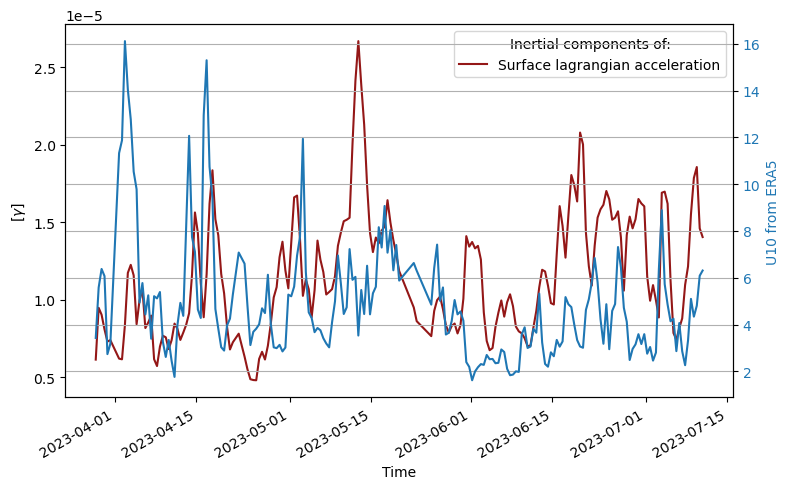

In [148]:
fig, ax = plt.subplots(figsize = (8, 5), frameon=False)

df0.acc.plot(label='Surface lagrangian acceleration', ax=ax, color = c0['acc'])
#df0.cor.plot(label='Surface Coriolis acceleration', ax=ax, color = c0['cor'])
#df15.acc.plot(label='15m Lagrangian acceleration', ax=ax, color = c0['acc'], ls=':')
#df15.cor.plot(label='15m Coriolis acceleration', ax=ax, color = c0['cor'], ls=':')
ax.set_ylabel(r'[$\gamma$]')
ax.legend(title='Inertial components of:')
ax.set_xlabel('Time')

ax = ax.twinx()  # instantiate a second Axes that shares the same x-axis
df0.U10.plot(ax=ax, label='U10 from ERA5')
ax.grid()
ax.tick_params(axis='y', labelcolor='tab:blue')
ax.set_ylabel('U10 from ERA5', color='tab:blue') 
ax.set_xlabel('Time')

fig.tight_layout()

# With era over the whole area

In [112]:
era = xr.open_dataset(os.path.join(zarr_dir, 'before_coloc', 'wind', 'era5_agesc_rio_z0.nc'))
era = era.where((era.longitude>df.longitude.min())&(era.longitude<df.longitude.max())&(era.latitude>df.latitude.min())&(era.latitude<df.latitude.max()), drop=True)  
era = era.sel(time = slice(df.datetime.min(), df.datetime.max()))

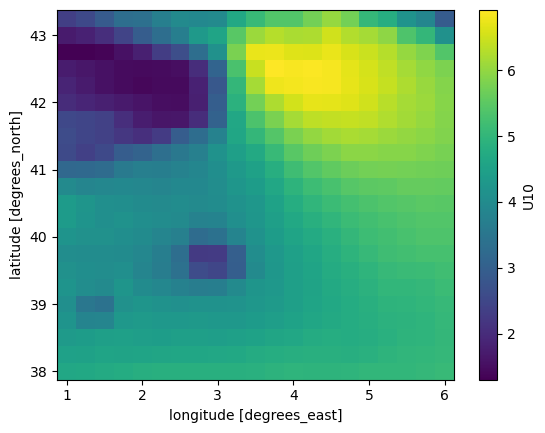

In [144]:
era.U10.mean('time').plot()

In [138]:
dt_bin = '12h'

df['time_sec'] = (df.datetime-df.datetime.min())/pd.Timedelta(dt_bin)//1

df0 = df[df.depth==0]
df15 = df[df.depth==15]

def give_acc(dfr):
    acc = dfr.groupby('time_sec')[['acc', 'cor']].mean().reset_index()
    acc['time'] = acc.time_sec*pd.Timedelta(dt_bin) + dfr.datetime.min()
    #acc['time'] = dss3.sel(cycle_number = acc.index.values).time.mean('num_lines').values
    from cstes import U, c0
    return acc.set_index('time')/U

acc0  = give_acc(df0)
acc15  = give_acc(df15)

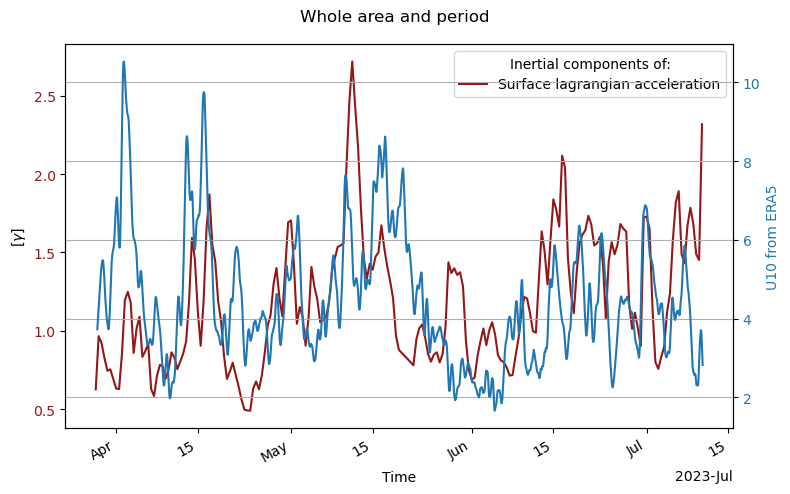

In [143]:
fig, ax = plt.subplots(figsize = (8, 5), frameon=False)

(acc0.acc).plot(label='Surface lagrangian acceleration', ax=ax, color = c0['acc'])
#(acc0.cor).plot(label='Surface Coriolis acceleration', ax=ax, color = c0['cor'])
#(acc15.acc).plot(label='15m Lagrangian acceleration', ax=ax, color = c0['acc'], ls=':')
#(acc15.cor).plot(label='15m Coriolis acceleration', ax=ax, color = c0['cor'], ls=':')
ax.set_ylabel(r'[$\gamma$]')
ax.legend(title='Inertial components of:')
ax.tick_params(axis='y', labelcolor= c0['acc'])
ax.set_xlabel('Time')

ax = ax.twinx()  # instantiate a second Axes that shares the same x-axis
(era.U10.rolling(time=12, center=True).mean('time').mean(['longitude', 'latitude'])).plot(ax=ax, label='U10 from ERA5')
ax.grid()
ax.tick_params(axis='y', labelcolor='tab:blue')
ax.set_ylabel('U10 from ERA5', color='tab:blue') 
ax.set_xlabel('Time')

fig.suptitle('Whole area and period')
fig.tight_layout()

# BioSWOT-Med area

In [112]:
lon = strcut

era = xr.open_dataset(os.path.join(zarr_dir, 'before_coloc', 'wind', 'era5_agesc_rio_z0.nc'))
era = era.where((era.longitude>df.longitude.min())&(era.longitude<df.longitude.max())&(era.latitude>df.latitude.min())&(era.latitude<df.latitude.max()), drop=True)  
era = era.sel(time = slice(df.datetime.min(), df.datetime.max()))